# Regressao Linear Multipla - ENEM 2024

Este notebook aplica regressao linear multipla para investigar quais caracteristicas educacionais e socioeconomicas disponiveis na base estao mais associadas ao desempenho medio dos participantes no ENEM 2024.

## 1. Objetivo

**Problema de pesquisa:** quais caracteristicas socioeconomicas e educacionais dos participantes estao mais associadas ao desempenho no ENEM 2024?

A tecnica escolhida e a **Regressao Linear Multipla**, pois permite modelar uma variavel resposta numerica continua a partir de varias variaveis explicativas, estimando a direcao e a magnitude da associacao de cada caracteristica com a nota media, mantendo as demais variaveis constantes.

**Variavel dependente:**

- `NOTA_MEDIA`: media de `NU_NOTA_CN`, `NU_NOTA_CH`, `NU_NOTA_LC`, `NU_NOTA_MT` e `NU_NOTA_REDACAO`.

**Variaveis independentes inicialmente propostas:**

- `TP_SEXO`, `TP_ESCOLA`, `SG_UF_RESIDENCIA`, `Q001`, `Q002`, `Q006`, `Q024`, `Q025`.

Como o notebook trabalha exclusivamente com a base real, as variaveis sao verificadas no cabecalho do arquivo. Caso alguma variavel proposta nao exista na base, ela e documentada como ausente e nao e usada no modelo. Variaveis educacionais/geograficas disponiveis na base de resultados tambem sao consideradas quando presentes.

## 2. Leitura dos dados

A leitura usa `encoding="latin1"` e `sep=";"`, selecionando apenas as colunas necessarias para a regressao.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "RESULTADOS_2024.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH

WindowsPath('c:/Users/mykaq/Desktop/Estudos/Unifesp/Ciência de Dados II/Projeto/cd2_analise_enem/data/raw/RESULTADOS_2024.csv')

In [2]:
SCORE_COLS = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO",
]

SUGGESTED_EXPLANATORY_COLS = [
    "TP_SEXO",
    "TP_ESCOLA",
    "SG_UF_RESIDENCIA",
    "Q001",
    "Q002",
    "Q006",
    "Q024",
    "Q025",
]

# Variaveis adicionais educacionais/geograficas presentes em bases de resultados do ENEM.
ADDITIONAL_EXPLANATORY_COLS = [
    "TP_DEPENDENCIA_ADM_ESC",
    "TP_LOCALIZACAO_ESC",
    "TP_LINGUA",
    "SG_UF_ESC",
    "SG_UF_PROVA",
]


def get_available_columns(csv_path: Path) -> list[str]:
    """Retorna o cabecalho do CSV sem carregar a base inteira."""
    return pd.read_csv(csv_path, sep=";", encoding="latin1", nrows=0).columns.tolist()


def select_model_columns(available_columns: list[str]) -> tuple[list[str], list[str], list[str]]:
    """Seleciona colunas de notas e explicativas que existem no arquivo real."""
    missing_scores = [col for col in SCORE_COLS if col not in available_columns]
    if missing_scores:
        raise ValueError(f"Colunas de nota ausentes no CSV: {missing_scores}")

    candidate_explanatory = SUGGESTED_EXPLANATORY_COLS + ADDITIONAL_EXPLANATORY_COLS
    explanatory_cols = [col for col in candidate_explanatory if col in available_columns]
    missing_suggested = [col for col in SUGGESTED_EXPLANATORY_COLS if col not in available_columns]
    usecols = SCORE_COLS + explanatory_cols
    return usecols, explanatory_cols, missing_suggested


available_columns = get_available_columns(RAW_PATH)
usecols, explanatory_cols, missing_suggested = select_model_columns(available_columns)

print(f"Total de colunas no arquivo: {len(available_columns)}")
print(f"Colunas usadas na modelagem: {usecols}")
print(f"Variaveis sugeridas ausentes na base: {missing_suggested}")

Total de colunas no arquivo: 42
Colunas usadas na modelagem: ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_LINGUA', 'SG_UF_ESC', 'SG_UF_PROVA']
Variaveis sugeridas ausentes na base: ['TP_SEXO', 'TP_ESCOLA', 'SG_UF_RESIDENCIA', 'Q001', 'Q002', 'Q006', 'Q024', 'Q025']


In [3]:
df_raw = pd.read_csv(
    RAW_PATH,
    sep=";",
    encoding="latin1",
    usecols=usecols,
    low_memory=False,
)

initial_records = len(df_raw)
print(f"Quantidade inicial de registros: {initial_records:,}")
df_raw.head()

Quantidade inicial de registros: 4,332,944


,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO
0,CE,2.0000,1.0000,CE,436.8000,377.8000,423.4000,427.1000,1,300.0000
1,SC,4.0000,1.0000,SC,521.9000,601.9000,605.5000,689.2000,0,920.0000
2,NaN,NaN,NaN,PR,363.0000,548.4000,557.2000,456.4000,1,480.0000
3,NaN,NaN,NaN,SP,550.7000,553.8000,605.9000,629.1000,0,740.0000
4,MA,2.0000,1.0000,MA,NaN,NaN,NaN,NaN,1,NaN


## 3. Preparacao dos dados

Transformacoes realizadas:

- criacao de `NOTA_MEDIA` como media das cinco notas;
- remocao de participantes sem nota em pelo menos uma das provas usadas na media;
- remocao de registros sem informacao nas variaveis explicativas selecionadas;
- conversao das variaveis explicativas para tipo categorico;
- codificacao one-hot das variaveis categoricas para uso na regressao linear.

In [4]:
def prepare_data(df: pd.DataFrame, explanatory_cols: list[str]) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Cria a variavel resposta e prepara X e y para modelagem."""
    model_df = df.copy()

    for col in SCORE_COLS:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    model_df["NOTA_MEDIA"] = model_df[SCORE_COLS].mean(axis=1, skipna=False)
    model_df = model_df.dropna(subset=SCORE_COLS + ["NOTA_MEDIA"])

    if not explanatory_cols:
        raise ValueError("Nenhuma variavel explicativa disponivel para modelagem.")

    model_df = model_df.dropna(subset=explanatory_cols).copy()

    for col in explanatory_cols:
        model_df[col] = model_df[col].astype("category")

    X = model_df[explanatory_cols]
    y = model_df["NOTA_MEDIA"]
    return model_df, X, y


model_df, X, y = prepare_data(df_raw, explanatory_cols)
final_records = len(model_df)

summary_preparation = pd.DataFrame({
    "etapa": ["Registros iniciais", "Registros finais apos preparacao", "Registros removidos"],
    "quantidade": [initial_records, final_records, initial_records - final_records],
})

summary_preparation.to_csv(TABLES_DIR / "regressao_preparacao_registros.csv", index=False, encoding="utf-8-sig")
summary_preparation

,etapa,quantidade
0,Registros iniciais,4332944
1,Registros finais apos preparacao,1193432
2,Registros removidos,3139512


In [5]:
variable_documentation = pd.DataFrame({
    "variavel": explanatory_cols + ["NOTA_MEDIA"],
    "papel": ["explicativa" for _ in explanatory_cols] + ["resposta"],
    "transformacao": ["codificacao one-hot; categoria de referencia omitida" for _ in explanatory_cols] + ["media aritmetica das cinco notas"],
})

missing_documentation = pd.DataFrame({
    "variavel_sugerida_ausente": missing_suggested,
    "observacao": "Variavel nao encontrada no cabecalho do arquivo RESULTADOS_2024.csv",
})

variable_documentation.to_csv(TABLES_DIR / "regressao_documentacao_variaveis.csv", index=False, encoding="utf-8-sig")
missing_documentation.to_csv(TABLES_DIR / "regressao_variaveis_sugeridas_ausentes.csv", index=False, encoding="utf-8-sig")

print("Documentacao das variaveis usadas:")
display(variable_documentation)

print("Variaveis sugeridas que nao existem na base carregada:")
display(missing_documentation)

Documentacao das variaveis usadas:


,variavel,papel,transformacao
0,TP_DEPENDENCIA_ADM_ESC,explicativa,codificacao one-hot; categoria de referencia o...
1,TP_LOCALIZACAO_ESC,explicativa,codificacao one-hot; categoria de referencia o...
2,TP_LINGUA,explicativa,codificacao one-hot; categoria de referencia o...
3,SG_UF_ESC,explicativa,codificacao one-hot; categoria de referencia o...
4,SG_UF_PROVA,explicativa,codificacao one-hot; categoria de referencia o...
5,NOTA_MEDIA,resposta,media aritmetica das cinco notas


Variaveis sugeridas que nao existem na base carregada:


,variavel_sugerida_ausente,observacao
0,TP_SEXO,Variavel nao encontrada no cabecalho do arquiv...
1,TP_ESCOLA,Variavel nao encontrada no cabecalho do arquiv...
2,SG_UF_RESIDENCIA,Variavel nao encontrada no cabecalho do arquiv...
3,Q001,Variavel nao encontrada no cabecalho do arquiv...
4,Q002,Variavel nao encontrada no cabecalho do arquiv...
5,Q006,Variavel nao encontrada no cabecalho do arquiv...
6,Q024,Variavel nao encontrada no cabecalho do arquiv...
7,Q025,Variavel nao encontrada no cabecalho do arquiv...


## 4. Construcao do modelo

Os dados sao divididos em 80% para treino e 20% para teste. O modelo principal usa `LinearRegression` do scikit-learn com codificacao one-hot para as variaveis categoricas.

In [6]:
def make_one_hot_encoder() -> OneHotEncoder:
    """Cria OneHotEncoder compativel com diferentes versoes do scikit-learn."""
    try:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)


def build_sklearn_model(categorical_cols: list[str]) -> Pipeline:
    """Monta pipeline com one-hot encoding e regressao linear."""
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                make_one_hot_encoder(),
                categorical_cols,
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

linear_model = build_sklearn_model(explanatory_cols)
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

print(f"Treino: {len(X_train):,} registros")
print(f"Teste: {len(X_test):,} registros")

Treino: 954,745 registros
Teste: 238,687 registros


## 5. Avaliacao do modelo

Metricas calculadas no conjunto de teste:

- `R2`: proporcao da variabilidade da nota media explicada pelo modelo;
- `MAE`: erro absoluto medio em pontos da nota;
- `RMSE`: raiz do erro quadratico medio em pontos da nota.

In [7]:
def evaluate_model(y_true: pd.Series, y_pred: np.ndarray) -> pd.DataFrame:
    """Calcula metricas de avaliacao do modelo."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics = pd.DataFrame({
        "metrica": ["R2", "MAE", "RMSE"],
        "valor": [r2_score(y_true, y_pred), mean_absolute_error(y_true, y_pred), rmse],
    })
    return metrics


metrics_df = evaluate_model(y_test, y_pred)
metrics_df.to_csv(TABLES_DIR / "regressao_metricas_modelo.csv", index=False, encoding="utf-8-sig")
metrics_df

,metrica,valor
0,R2,0.3123
1,MAE,60.3791
2,RMSE,76.1931


## 6. Interpretacao dos coeficientes

Para obter erro padrao, estatistica t e p-value, o mesmo conjunto de treino e ajustado com `statsmodels.OLS` sobre a matriz codificada. A interpretacao dos coeficientes considera associacao condicional, nao causalidade.

In [8]:
def make_design_matrix(X_train: pd.DataFrame, X_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Cria matrizes one-hot alinhadas para statsmodels."""
    X_train_dummies = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_test_dummies = pd.get_dummies(X_test, drop_first=True, dtype=float)
    X_test_dummies = X_test_dummies.reindex(columns=X_train_dummies.columns, fill_value=0.0)

    X_train_sm = sm.add_constant(X_train_dummies, has_constant="add")
    X_test_sm = sm.add_constant(X_test_dummies, has_constant="add")
    return X_train_sm, X_test_sm


def fit_statsmodels_ols(X_train_sm: pd.DataFrame, y_train: pd.Series):
    """Ajusta OLS com statsmodels para inferencia estatistica."""
    return sm.OLS(y_train.astype(float), X_train_sm.astype(float)).fit()


X_train_sm, X_test_sm = make_design_matrix(X_train, X_test)
ols_model = fit_statsmodels_ols(X_train_sm, y_train)

coef_table = pd.DataFrame({
    "variavel": ols_model.params.index,
    "coeficiente": ols_model.params.values,
    "erro_padrao": ols_model.bse.values,
    "estatistica_t": ols_model.tvalues.values,
    "p_value": ols_model.pvalues.values,
})

coef_table = coef_table[coef_table["variavel"] != "const"].copy()
coef_table["coeficiente_absoluto"] = coef_table["coeficiente"].abs()
coef_table["direcao_efeito"] = np.where(coef_table["coeficiente"] >= 0, "positivo", "negativo")
coef_table["significativo_5pct"] = np.where(coef_table["p_value"] < 0.05, "sim", "nao")
coef_table = coef_table.sort_values("coeficiente_absoluto", ascending=False).reset_index(drop=True)

coef_table.to_csv(TABLES_DIR / "regressao_coeficientes_inferencia.csv", index=False, encoding="utf-8-sig")
coef_table.head(20)

,variavel,coeficiente,erro_padrao,estatistica_t,p_value,coeficiente_absoluto,direcao_efeito,significativo_5pct
0,TP_DEPENDENCIA_ADM_ESC_2.0,-77.3611,0.3599,-214.9684,0.0000,77.3611,negativo,sim
1,TP_DEPENDENCIA_ADM_ESC_3.0,-54.9556,1.1059,-49.6947,0.0000,54.9556,negativo,sim
2,SG_UF_ESC_AL,-37.2146,9.9621,-3.7356,0.0002,37.2146,negativo,sim
3,TP_LINGUA_1,-36.7957,0.1674,-219.7742,0.0000,36.7957,negativo,sim
4,SG_UF_ESC_RR,-33.5771,21.9696,-1.5283,0.1264,33.5771,negativo,nao
5,SG_UF_PROVA_RR,31.2494,21.9421,1.4242,0.1544,31.2494,positivo,nao
6,SG_UF_ESC_PA,-31.1191,8.9456,-3.4787,0.0005,31.1191,negativo,sim
7,SG_UF_PROVA_MG,25.2326,9.2216,2.7363,0.0062,25.2326,positivo,sim
8,SG_UF_PROVA_SC,23.9738,9.5382,2.5134,0.0120,23.9738,positivo,sim
9,SG_UF_ESC_AM,-23.7737,8.2864,-2.8690,0.0041,23.7737,negativo,sim


In [9]:
top10_coef = coef_table.head(10).copy()
top10_coef.to_csv(TABLES_DIR / "regressao_top10_variaveis_influentes.csv", index=False, encoding="utf-8-sig")

def interpret_coefficient(row: pd.Series) -> str:
    """Gera interpretacao textual padronizada para um coeficiente."""
    direction = "positiva" if row["coeficiente"] >= 0 else "negativa"
    tendency = "maior" if row["coeficiente"] >= 0 else "menor"
    significance = "estatisticamente significativa" if row["p_value"] < 0.05 else "nao estatisticamente significativa ao nivel de 5%"
    return (
        f"A variavel {row['variavel']} apresentou associacao {direction} com a nota media "
        f"(coeficiente = {row['coeficiente']:.2f}; p-value = {row['p_value']:.4f}), "
        f"indicando desempenho medio {tendency} em relacao a categoria de referencia, "
        f"mantidas constantes as demais variaveis. Essa associacao e {significance}."
    )

interpretations = pd.DataFrame({
    "variavel": top10_coef["variavel"],
    "interpretacao": top10_coef.apply(interpret_coefficient, axis=1),
})

interpretations.to_csv(TABLES_DIR / "regressao_interpretacao_top10.csv", index=False, encoding="utf-8-sig")

for text in interpretations["interpretacao"]:
    print(f"- {text}")

- A variavel TP_DEPENDENCIA_ADM_ESC_2.0 apresentou associacao negativa com a nota media (coeficiente = -77.36; p-value = 0.0000), indicando desempenho medio menor em relacao a categoria de referencia, mantidas constantes as demais variaveis. Essa associacao e estatisticamente significativa.
- A variavel TP_DEPENDENCIA_ADM_ESC_3.0 apresentou associacao negativa com a nota media (coeficiente = -54.96; p-value = 0.0000), indicando desempenho medio menor em relacao a categoria de referencia, mantidas constantes as demais variaveis. Essa associacao e estatisticamente significativa.
- A variavel SG_UF_ESC_AL apresentou associacao negativa com a nota media (coeficiente = -37.21; p-value = 0.0002), indicando desempenho medio menor em relacao a categoria de referencia, mantidas constantes as demais variaveis. Essa associacao e estatisticamente significativa.
- A variavel TP_LINGUA_1 apresentou associacao negativa com a nota media (coeficiente = -36.80; p-value = 0.0000), indicando desempenho me

In [10]:
significance_summary = pd.DataFrame({
    "criterio": [
        "Coeficientes avaliados",
        "Significativos ao nivel de 5%",
        "Nao significativos ao nivel de 5%",
    ],
    "quantidade": [
        len(coef_table),
        int((coef_table["p_value"] < 0.05).sum()),
        int((coef_table["p_value"] >= 0.05).sum()),
    ],
})

significant_vars = coef_table.loc[coef_table["p_value"] < 0.05, "variavel"].tolist()
significance_summary.to_csv(TABLES_DIR / "regressao_resumo_significancia.csv", index=False, encoding="utf-8-sig")

display(significance_summary)
print("Variaveis estatisticamente significativas ao nivel de 5%:")
print(significant_vars)

,criterio,quantidade
0,Coeficientes avaliados,57
1,Significativos ao nivel de 5%,18
2,Nao significativos ao nivel de 5%,39


Variaveis estatisticamente significativas ao nivel de 5%:
['TP_DEPENDENCIA_ADM_ESC_2.0', 'TP_DEPENDENCIA_ADM_ESC_3.0', 'SG_UF_ESC_AL', 'TP_LINGUA_1', 'SG_UF_ESC_PA', 'SG_UF_PROVA_MG', 'SG_UF_PROVA_SC', 'SG_UF_ESC_AM', 'SG_UF_PROVA_GO', 'SG_UF_ESC_AP', 'SG_UF_PROVA_RS', 'TP_LOCALIZACAO_ESC_2.0', 'SG_UF_ESC_BA', 'SG_UF_ESC_TO', 'SG_UF_ESC_PB', 'SG_UF_ESC_MA', 'SG_UF_PROVA_PB', 'TP_DEPENDENCIA_ADM_ESC_4.0']


## 7. Diagnosticos do modelo

Sao avaliados:

- distribuicao dos residuos;
- residuos versus valores previstos;
- indicios visuais de heterocedasticidade;
- multicolinearidade por VIF.

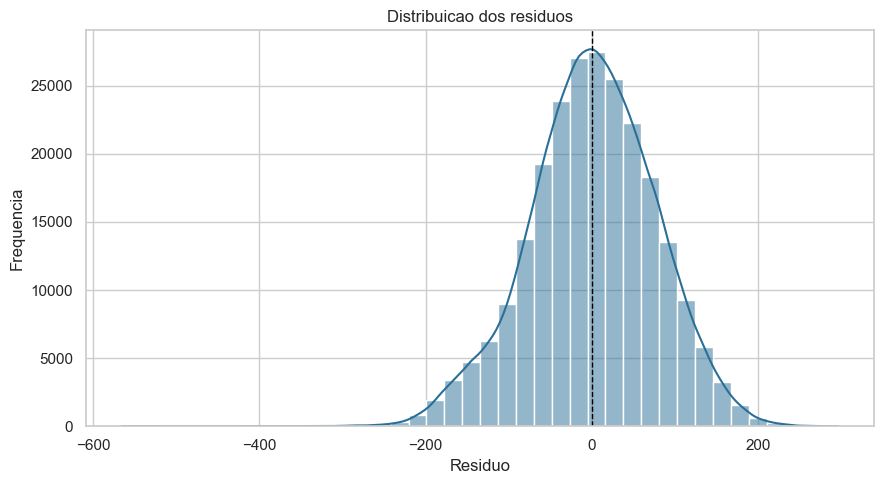

In [11]:
residuals = y_test - y_pred
predicted_df = pd.DataFrame({
    "valor_observado": y_test,
    "valor_previsto": y_pred,
    "residuo": residuals,
})
predicted_df.to_csv(TABLES_DIR / "regressao_residuos_teste.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(residuals, kde=True, bins=40, ax=ax, color="#2A6F97")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Distribuicao dos residuos")
ax.set_xlabel("Residuo")
ax.set_ylabel("Frequencia")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "regressao_distribuicao_residuos.png", dpi=300, bbox_inches="tight")
plt.show()

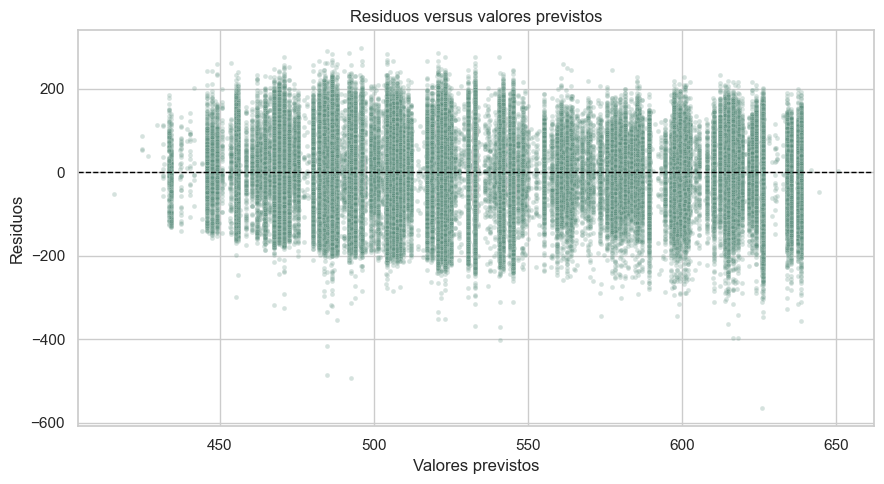

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.25, s=12, ax=ax, color="#5B8E7D")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residuos versus valores previstos")
ax.set_xlabel("Valores previstos")
ax.set_ylabel("Residuos")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "regressao_residuos_vs_previstos.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
def calculate_vif(X_design: pd.DataFrame, max_rows: int = 200_000) -> pd.DataFrame:
    """Calcula VIF para a matriz de treino codificada, com amostra se necessario."""
    X_no_const = X_design.drop(columns=["const"], errors="ignore").copy()

    # O VIF pode ser custoso em bases grandes; a amostra preserva viabilidade computacional.
    if len(X_no_const) > max_rows:
        X_no_const = X_no_const.sample(max_rows, random_state=42)

    vif_values = []
    values = X_no_const.astype(float).values
    for idx, col in enumerate(X_no_const.columns):
        vif_values.append(variance_inflation_factor(values, idx))

    vif_df = pd.DataFrame({
        "variavel": X_no_const.columns,
        "VIF": vif_values,
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_df


vif_df = calculate_vif(X_train_sm)
vif_df.to_csv(TABLES_DIR / "regressao_vif.csv", index=False, encoding="utf-8-sig")
vif_df.head(20)

,variavel,VIF
0,SG_UF_ESC_RR,inf
1,SG_UF_PROVA_RR,inf
2,SG_UF_ESC_SP,"2,199.0312"
3,SG_UF_PROVA_SP,"2,198.3106"
4,SG_UF_ESC_MG,"1,001.4275"
5,SG_UF_PROVA_MG,994.2414
6,SG_UF_ESC_CE,989.4106
7,SG_UF_PROVA_CE,984.5924
8,SG_UF_ESC_BA,969.4106
9,SG_UF_PROVA_BA,964.0929


In [14]:
def diagnostic_interpretation(residuals: pd.Series, y_pred: np.ndarray, vif_df: pd.DataFrame) -> list[str]:
    """Gera comentarios objetivos sobre os diagnosticos."""
    residual_mean = float(np.mean(residuals))
    residual_std = float(np.std(residuals))
    corr_abs_pred_resid = abs(float(np.corrcoef(y_pred, residuals)[0, 1]))
    high_vif_count = int((vif_df["VIF"] > 10).sum())

    comments = [
        f"A media dos residuos foi {residual_mean:.2f}, valor proximo de zero esperado em modelos lineares ajustados com intercepto.",
        f"O desvio padrao dos residuos foi {residual_std:.2f} pontos, indicando a dispersao media dos erros em torno das previsoes.",
        f"A correlacao absoluta entre valores previstos e residuos foi {corr_abs_pred_resid:.3f}; valores altos sugeririam padrao sistematico nao capturado pelo modelo.",
        f"Foram identificadas {high_vif_count} variaveis codificadas com VIF acima de 10, criterio usual de alerta para multicolinearidade elevada.",
        "A heterocedasticidade deve ser avaliada visualmente no grafico de residuos versus previstos: aumento ou reducao clara da dispersao ao longo das previsoes sugere variancia nao constante dos erros.",
    ]
    return comments


for comment in diagnostic_interpretation(residuals, y_pred, vif_df):
    print(f"- {comment}")

- A media dos residuos foi 0.17, valor proximo de zero esperado em modelos lineares ajustados com intercepto.
- O desvio padrao dos residuos foi 76.19 pontos, indicando a dispersao media dos erros em torno das previsoes.
- A correlacao absoluta entre valores previstos e residuos foi 0.002; valores altos sugeririam padrao sistematico nao capturado pelo modelo.
- Foram identificadas 53 variaveis codificadas com VIF acima de 10, criterio usual de alerta para multicolinearidade elevada.
- A heterocedasticidade deve ser avaliada visualmente no grafico de residuos versus previstos: aumento ou reducao clara da dispersao ao longo das previsoes sugere variancia nao constante dos erros.


## 8. Conclusao

Execute a celula abaixo apos o ajuste do modelo para gerar um resumo textual pronto para ser incorporado ao relatorio academico.

In [15]:
def build_conclusion(metrics_df: pd.DataFrame, coef_table: pd.DataFrame, vif_df: pd.DataFrame) -> str:
    """Gera conclusao textual com fatores, qualidade do modelo, limitacoes e melhorias."""
    r2 = float(metrics_df.loc[metrics_df["metrica"] == "R2", "valor"].iloc[0])
    mae = float(metrics_df.loc[metrics_df["metrica"] == "MAE", "valor"].iloc[0])
    rmse = float(metrics_df.loc[metrics_df["metrica"] == "RMSE", "valor"].iloc[0])
    top_vars = coef_table.head(10)["variavel"].tolist()
    significant_count = int((coef_table["p_value"] < 0.05).sum())
    high_vif_count = int((vif_df["VIF"] > 10).sum())

    conclusion = f"""
A regressao linear multipla indicou que as variaveis mais associadas ao desempenho medio no ENEM 2024 foram: {', '.join(top_vars)}. Os sinais dos coeficientes mostram se cada categoria esta associada a notas medias maiores ou menores em relacao a categoria de referencia, mantendo as demais variaveis constantes.

A qualidade preditiva do modelo, avaliada no conjunto de teste, apresentou R2 = {r2:.4f}, MAE = {mae:.2f} pontos e RMSE = {rmse:.2f} pontos. Assim, o modelo deve ser interpretado principalmente como uma ferramenta de analise de associacoes entre caracteristicas observadas e desempenho, e nao como um modelo causal.

Ao nivel de significancia de 5%, {significant_count} coeficientes foram estatisticamente significativos. Esse resultado indica que parte das categorias incluidas possui evidencia estatistica de associacao com a nota media, condicionada as demais variaveis do modelo.

As principais limitacoes sao: ausencia, nesta base carregada, de algumas variaveis socioeconomicas sugeridas; natureza observacional dos dados; possibilidade de variaveis omitidas; e uso de relacoes lineares para representar um fenomeno educacional complexo. A analise de VIF apontou {high_vif_count} variaveis com VIF acima de 10, o que pode indicar multicolinearidade em parte das variaveis codificadas.

Como melhorias futuras, recomenda-se incorporar a base completa com questionario socioeconomico quando disponivel, testar modelos com regularizacao, avaliar interacoes entre variaveis educacionais e territoriais, e comparar os resultados com modelos nao lineares mantendo a regressao linear como linha de base interpretavel.
""".strip()
    return conclusion


conclusion_text = build_conclusion(metrics_df, coef_table, vif_df)
with open(TABLES_DIR / "regressao_conclusao.txt", "w", encoding="utf-8") as file:
    file.write(conclusion_text)

print(conclusion_text)

A regressao linear multipla indicou que as variaveis mais associadas ao desempenho medio no ENEM 2024 foram: TP_DEPENDENCIA_ADM_ESC_2.0, TP_DEPENDENCIA_ADM_ESC_3.0, SG_UF_ESC_AL, TP_LINGUA_1, SG_UF_ESC_RR, SG_UF_PROVA_RR, SG_UF_ESC_PA, SG_UF_PROVA_MG, SG_UF_PROVA_SC, SG_UF_ESC_AM. Os sinais dos coeficientes mostram se cada categoria esta associada a notas medias maiores ou menores em relacao a categoria de referencia, mantendo as demais variaveis constantes.

A qualidade preditiva do modelo, avaliada no conjunto de teste, apresentou R2 = 0.3123, MAE = 60.38 pontos e RMSE = 76.19 pontos. Assim, o modelo deve ser interpretado principalmente como uma ferramenta de analise de associacoes entre caracteristicas observadas e desempenho, e nao como um modelo causal.

Ao nivel de significancia de 5%, 18 coeficientes foram estatisticamente significativos. Esse resultado indica que parte das categorias incluidas possui evidencia estatistica de associacao com a nota media, condicionada as demais v